# Parte 1: Análisis Exploratorio de Datos (EDA)

Nota: Eliminé partes del codigo que corresponden a la interacción con la API de Caterpillar. Aunque no hay claves en en el script, y no es posible instalar esta libería fuera de los equipos y red de la empresa, temo que la mención a esta, o algunos terminos pueda levantar alarmas a los sistemas automatizados de ciberseguridad al subir al repo del ITESM (Lo digo por experiencia)


# 1. Procesamiento inicial del Dataset

Se descargan los datos a traves de API, se delimita el y etiqueta el el dataset basado en GPS 

## Configuración e importación de librerías


In [ ]:
import re
import time
import warnings
from datetime import date

import numpy as np
import pandas as pd
import polars as pl

import matplotlib.pyplot as plt
import seaborn as sns



# warnings.filterwarnings("ignore")
# sns.set_theme(style="whitegrid", context="notebook")
# plt.rcParams["figure.dpi"] = 100



## Carga de datos desde API

Se autentica contra API, se descubren los canales disponibles para la máquina y se descarga la
ventana temporal completa como `polars.DataFrame`. Posteriormente se convierte a `pandas` para el EDA.


In [ ]:
# --- Parámetros del experimento ---
SERIAL_NUMBER = "M9P00246"  # Reemplazar con el número de serie real
START_DATE    = date(2026, 2, 1)
STOP_DATE     = date(2026, 2, 2)


day_or_range = [START_DATE, STOP_DATE]

In [ ]:
### Aceso API a canales disponibles ###

Canales disponibles para M9P00224: 300

  - SPD_XMSN_IN
  - Tout_torq_conv_ratio
  - obcm_str_counts_04micron
  - EDDT_CAN1_MID00_C298_F3_W1
  - obcm_imp_alarm_laser_current_high
  - CMD_PMP_RT_FT
  - keyswitch
  - lift_seg_cycle
  - obcm_imp_flow_index
  - STAT_START_RELAY
  - PFC_MAP_PMP_CMD
  - obcm_imp_viscosity
  - obcm_str_density
  - AIR_INLET_TMP
  - PRCNT_ALUB_GRS_LVL
  - seg_loop_cnt
  - SW_PT_FLTR_BYPS
  - FLW_IMP_MAX_AVAIL
  - ___valve_tilt_percent
  - ParkBrakeSolCmd
  - PRS_LIFT_CYL_RE
  - obcm_imp_alarm_photodiode_voltage_low
  - total_pump_displacement
  - ENGSPD_DES
  - obcm_imp_alarm_temperature_high
  - Trans SW Group Part Number (CDL)
  - PS_trq_stat
  - GEAR_NUM
  - Eng SW Group Info
  - Grnd_Lvl_Shtdwn_Switch
  - obcm_str_alarm_photodiode_voltage_high
  - obcm_str_alarm_laser_current_high
  - EDDT_CDL1_MID51_C596_F9_W1
  - BATT_VOLT_TRAN
  - Eng EDDT Diags
  - FuelOutletPressFiltered
  - SC2 CDL1 Bus Load
  - SW_HYD_OIL_LVL
  - obcm_imp_alarm_high_flow
  - obcm_st

In [ ]:
# Cargar lista de canales desde el CSV "filtered_picked"
# picked_csv = f"channels_{SERIAL_NUMBER}_filtered_picked.csv"
picked_csv = f"channels_M9P00246_filtered_picked.csv" 
channels_picked = pd.read_csv(picked_csv).iloc[:, 0].dropna().astype(str).tolist()
print(f"Canales cargados desde {picked_csv}: {len(channels_picked)}")

# Descargar SOLO los canales del CSV filtered_picked
#### DESCARGA DE DATOS ATRAVES DE API ####

df = df_raw.to_pandas()

# Verificación rápida del rango temporal
ts_min, ts_max = df["date_time"].min(), df["date_time"].max()
print(f"Rango date_time: {ts_min}  →  {ts_max}")

print(f"Shape (filas x columnas): {df.shape}")
print(f"Memoria aproximada: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head(3)


Canales cargados desde channels_M9P00246_filtered_picked.csv: 35
Rango date_time: 2026-02-01 00:00:00.029000  →  2026-02-01 23:59:59.997000
Shape (filas x columnas): (403420, 37)
Memoria aproximada: 79.1 MB


,GLOBAL_TIME,brake_eng_spd_val,ceal_sensor_temp_exhaust_left,ceal_sensor_temp_exhaust_left2,ceal_sensor_temp_exhaust_right,ceal_sensor_temp_exhaust_right2,Comp_brake_actual_level,Coolant_Lvl_Input,Coolant_Pressure_Abs,Coolant_Pressure_Gauge,...,SW_STR_OIL_LVL,Throttle_Lock_Speed,Throttle_Position,TMP_AXL_OIL_F,TMP_AXL_OIL_R,TMP_HYD_OIL,TMP_STR_BRK_OIL,TMP_TC_OIL,TMP_XMSN_OIL,date_time
0,99852.000000,1566.875,553.4375,549.5625,546.40625,539.375,0.0,0.0,275.93750,176.84375,...,0.0,0.0,65.536545,54.75,52.695312,60.871084,64.644763,112.09375,90.421875,2026-02-01 00:00:00.029000
1,99852.000002,1559.375,553.4375,549.5625,546.40625,539.375,0.0,0.0,264.15625,168.53125,...,0.0,0.0,64.044235,54.75,52.695312,60.871084,64.644763,112.09375,90.421875,2026-02-01 00:00:00.148999
2,99852.000003,1555.625,553.4375,549.5625,546.40625,539.375,0.0,0.0,264.15625,168.53125,...,0.0,0.0,64.044235,54.75,52.695312,60.871084,64.644763,112.09375,90.421875,2026-02-01 00:00:00.269000


## Mapeado de GPS

Puntos GPS válidos: 390,789


ConnectionError: ('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None))

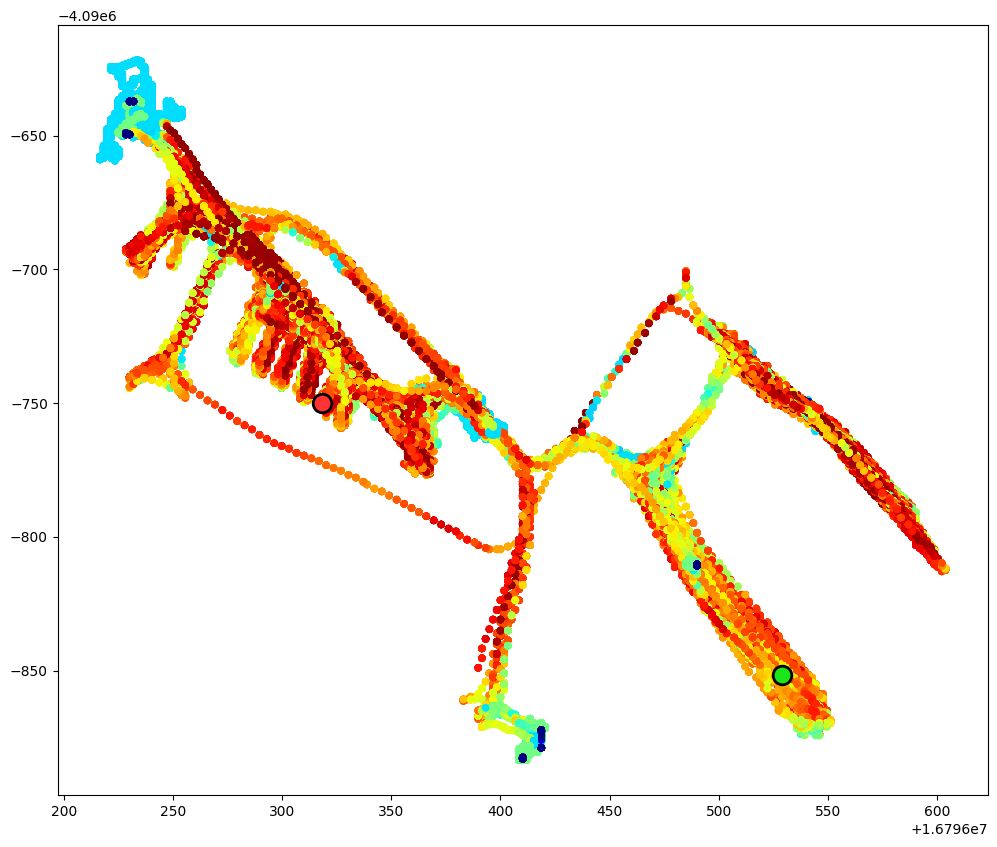

In [ ]:
# Mapa satelital ESTÁTICO (imagen PNG) de puntos GPS coloreados por RPM (ENGSPD).
# Réplica del plot MATLAB: scatter coloreado por Engine Speed con marcadores Start/End.
import subprocess, sys

def _ensure(pkg, import_name=None):
    try:
        __import__(import_name or pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

_ensure("contextily")
import contextily as cx

# --- Búsqueda robusta de columnas (equivalente a regexprep en MATLAB) ---
norm_vars = {c: re.sub(r"[^a-z0-9]", "", c.lower()) for c in df.columns}
lat_col = next((c for c, n in norm_vars.items()
                if ("gpgga" in n or "gps" in n) and "latitude"  in n), None)
lon_col = next((c for c, n in norm_vars.items()
                if ("gpgga" in n or "gps" in n) and "longitude" in n), None)
rpm_col = next((c for c, n in norm_vars.items() if "engspd" in n), None)

if lat_col is None or lon_col is None:
    raise ValueError("Could not find GPGGA latitude/longitude columns in data.")
if rpm_col is None:
    raise ValueError("Could not find ENGSPD channel in data.")

gps = df[[lat_col, lon_col, rpm_col]].copy()
valid = (
    np.isfinite(gps[lat_col]) & np.isfinite(gps[lon_col]) & np.isfinite(gps[rpm_col])
    & ((gps[lat_col] != 0) | (gps[lon_col] != 0))
)
gps = gps[valid].reset_index(drop=True)
if gps.empty:
    raise ValueError("No valid GPS points found to plot.")
print(f"Puntos GPS válidos: {len(gps):,}")

# Etiqueta de rango de fechas (equivalente a date_range_label en MATLAB)
date_range_label = f"{START_DATE} to {STOP_DATE}"
asset_sn = SERIAL_NUMBER

# Reproyección WGS84 -> Web Mercator (EPSG:3857) sin pyproj (fórmula directa)
R = 6378137.0
def wgs84_to_merc(lat_deg, lon_deg):
    lat_rad = np.deg2rad(np.asarray(lat_deg, dtype=float))
    x = R * np.deg2rad(np.asarray(lon_deg, dtype=float))
    y = R * np.log(np.tan(np.pi / 4 + lat_rad / 2))
    return x, y

xs, ys = wgs84_to_merc(gps[lat_col].values, gps[lon_col].values)

fig, ax = plt.subplots(figsize=(12, 10))
sc = ax.scatter(xs, ys, c=gps[rpm_col].values, cmap="jet",
                s=30, alpha=0.9, edgecolors="none")

# Marcadores Start (verde) y End (rojo)
ax.scatter(xs[0], ys[0], s=180, c="#1ae61a", edgecolors="k",
           linewidths=2, zorder=5, label="Start")
ax.scatter(xs[-1], ys[-1], s=180, c="#ff3333", edgecolors="k",
           linewidths=2, zorder=5, label="End")

# Padding alrededor de los puntos
pad_x = (xs.max() - xs.min()) * 0.05 or 50
pad_y = (ys.max() - ys.min()) * 0.05 or 50
ax.set_xlim(xs.min() - pad_x, xs.max() + pad_x)
ax.set_ylim(ys.min() - pad_y, ys.max() + pad_y)

# Tiles satelitales de Esri World Imagery (equivalente a geobasemap satellite)
cx.add_basemap(ax, source=cx.providers.Esri.WorldImagery, crs="EPSG:3857")

cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label("Engine Speed (RPM)")
ax.set_title(f"GPS Track (GPGGA) | {date_range_label}")
ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc="best")
plt.tight_layout()
plt.show()


## Etiquetado del estado operativo (`Status`)

Reglas geo-espaciales (consistentes con el notebook base):

- **Working**: `lat < -34.45939 & lon > 150.88328`
- **not_Working**: `lat > -34.45939 & lon > 150.88328`
- **travel**: el resto

`Status` será nuestra **variable objetivo** durante el EDA.

Las columnas de `GPS` tambi'en son elminadas ya que con esas se creo la variable objetivo y causarían data leakage


In [18]:
# Clasificación del estado de la máquina (réplica del bloque MATLAB)
lat = df["GPGGA Latitude"]  # df[lat_col]
lon = df["GPGGA Longitude"]  # df[lon_col]

# --- Definición de condiciones working / not_working SIN RPM ---
ref_lat  = -34.45939
ref_long = 150.88328

# Equivalente MATLAB:
#   working     = (lat < ref_lat) & (lon > ref_long);
#   not_working = (lat > ref_lat) & (lon < ref_long);
working     = (lat < ref_lat)  & (lon > ref_long)
not_working = (lat > ref_lat)  & (lon < ref_long)

# Nueva columna 'status' a partir de las máscaras working / not_working.
# Cualquier punto que no caiga en ninguna región queda como "other".
df["status"] = np.select(
    [working.fillna(False), not_working.fillna(False)],
    ["working", "not_working"],
    default="other",
)


# Sincronizar máscaras con el df ya filtrado
working     = df["status"].eq("working")
not_working = df["status"].eq("not_working")

# Conteo de observaciones en cada categoría
status_counts = df["status"].value_counts(dropna=False)
status_pct    = (status_counts / len(df) * 100).round(2)
print("\nConteo de observaciones por status:")
print(pd.concat([status_counts.rename("n"), status_pct.rename("%")], axis=1))




Conteo de observaciones por status:
                  n      %
status                    
working      355369  88.09
not_working   39739   9.85
other          8312   2.06


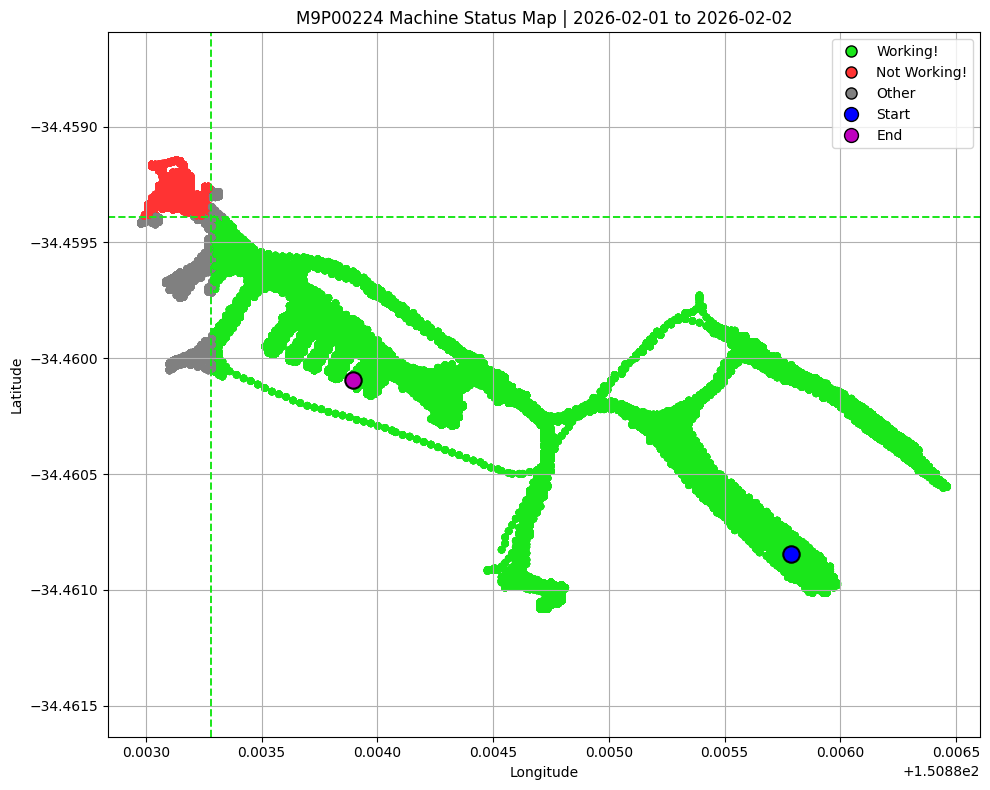

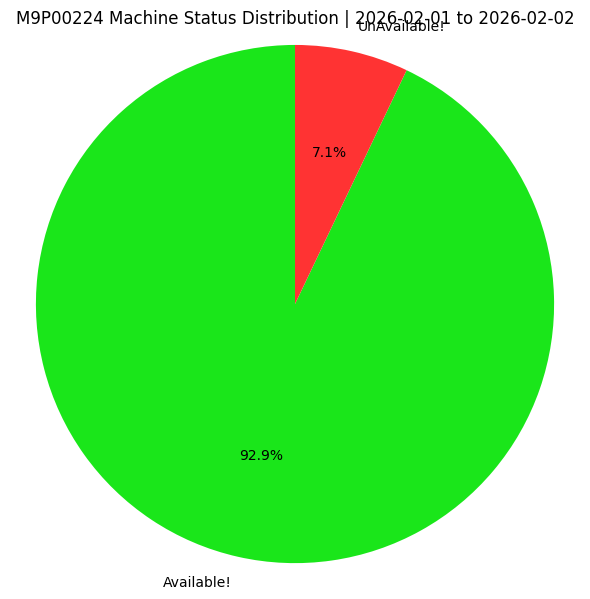


=== Machine Status Analysis ===
Asset: M9P00224
Date Range: 2026-02-01 to 2026-02-02
Working: 355369 observations (92.9%)
Not Working: 27108 observations (7.1%)

Columnas eliminadas por data leakage: ['GPGGA Latitude', 'GPGGA Longitude']
Filas 'other' eliminadas: 8,312  |  Filas restantes: 395,108


In [19]:
# Plotting - Machine Status Map + Pie Chart (réplica del bloque MATLAB)

# --- Filtro de puntos GPS válidos (mismo criterio que el plot anterior) ---
valid = (
    np.isfinite(lat) & np.isfinite(lon)
    & ((lat != 0) | (lon != 0))
)
lat_v = lat[valid].reset_index(drop=True)
lon_v = lon[valid].reset_index(drop=True)

# Máscaras booleanas como numpy (alineadas por posición con lat_v/lon_v)
working_v     = working[valid].to_numpy()
not_working_v = not_working[valid].to_numpy()

num_working     = int(working_v.sum())
num_not_working = int(not_working_v.sum())

# --- Colores: verde working, rojo not_working, gris el resto ---
GREEN = (0.1, 0.9, 0.1)
RED   = (1.0, 0.2, 0.2)
GRAY  = (0.5, 0.5, 0.5)

colors = np.tile(np.array(GRAY), (len(lat_v), 1))
colors[working_v]     = GREEN
colors[not_working_v] = RED

# =========================
# Figure 2: Machine Status Map
# =========================
fig2, ax2 = plt.subplots(figsize=(10, 8))
ax2.scatter(lon_v, lat_v, s=30, c=colors, edgecolors="none")

# Start (azul) y End (magenta)
ax2.scatter(lon_v.iloc[0],  lat_v.iloc[0],  s=140, c="b", edgecolors="k",
            linewidths=1.5, zorder=5, label="Start")
ax2.scatter(lon_v.iloc[-1], lat_v.iloc[-1], s=140, c="m", edgecolors="k",
            linewidths=1.5, zorder=5, label="End")

# Líneas de umbral
ax2.axvline(ref_long, ls="--", color=GREEN, lw=1.4)
ax2.axhline(ref_lat,  ls="--", color=GREEN, lw=1.4)

# Leyenda personalizada
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor=GREEN,
           markersize=8, label="Working!"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor=RED,
           markersize=8, label="Not Working!"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor=GRAY,
           markersize=8, label="Other"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="b",
           markeredgecolor="k", markersize=10, label="Start"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="m",
           markeredgecolor="k", markersize=10, label="End"),
]
ax2.legend(handles=legend_handles, loc="best")

ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")
ax2.set_title(f"{asset_sn} Machine Status Map | {date_range_label}")
ax2.set_aspect("equal", adjustable="datalim")
ax2.grid(True)
plt.tight_layout()
plt.show()

# =========================
# Figure 3: Pie chart
# =========================
fig3, ax3 = plt.subplots(figsize=(6, 6))
ax3.pie(
    [num_working, num_not_working],
    labels=["Available!", "UnAvailable!"],
    colors=[GREEN, RED],
    autopct="%1.1f%%",
    startangle=90,
)
ax3.set_title(f"{asset_sn} Machine Status Distribution | {date_range_label}")
ax3.axis("equal")
plt.tight_layout()
plt.show()

# =========================
# Estadísticas (fprintf MATLAB)
# =========================
total = num_working + num_not_working
pct_w  = 100 * num_working / total if total else 0.0
pct_nw = 100 * num_not_working / total if total else 0.0

print("\n=== Machine Status Analysis ===")
print(f"Asset: {asset_sn}")
print(f"Date Range: {START_DATE} to {STOP_DATE}")
print(f"Working: {num_working} observations ({pct_w:.1f}%)")
print(f"Not Working: {num_not_working} observations ({pct_nw:.1f}%)")
print("=============================\n")

# Eliminar las columnas GPS usadas para construir 'status' (evita data leakage)
leak_cols = [c for c in ["GPGGA Latitude", "GPGGA Longitude"] if c in df.columns]
df = df.drop(columns=leak_cols)
print(f"Columnas eliminadas por data leakage: {leak_cols}")

# Eliminar las filas que cayeron en "other" (no cumplen ninguna regla geo)
n_before = len(df)
df = df[df["status"] != "other"].reset_index(drop=True)
print(f"Filas 'other' eliminadas: {n_before - len(df):,}  |  Filas restantes: {len(df):,}")


# 2. Analisis exploratorio de los datos (EDA)

Tipos de datos, correlaciones, valores atipicos, distribuciones, etc. 


## 1. Clasificacion de variables

Todas las features son numericas

In [20]:
# Detectar columnas temporales (timestamp/datetime/date en el nombre o dtype)
datetime_cols = [
    c for c in df.columns
    if pd.api.types.is_datetime64_any_dtype(df[c])
    or any(tok in c.lower() for tok in ["timestamp", "datetime"])
]
# Numéricas
numeric_cols = df.select_dtypes(include=["number", "bool"]).columns.tolist()
# Categóricas / texto (excluyendo target y temporales)
categorical_cols = [
    c for c in df.columns
    if c not in numeric_cols and c not in datetime_cols and c != "Status"
]

overview = pd.DataFrame({
    "tipo": ["filas", "columnas totales", "numéricas",
             "categóricas", "temporales", "target (Status)"],
    "valor": [len(df), df.shape[1], len(numeric_cols),
              len(categorical_cols), len(datetime_cols), 1],
})
print(overview.to_string(index=False))
print("\nMuestra de columnas categóricas:", categorical_cols[:10])
print("Columnas temporales detectadas:", datetime_cols[:5])


            tipo  valor
           filas 395108
columnas totales     36
       numéricas     34
     categóricas      1
      temporales      1
 target (Status)      1

Muestra de columnas categóricas: ['status']
Columnas temporales detectadas: ['date_time']


## 2. Valores faltantes


In [21]:
# Tabla resumen de faltantes
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_summary = pd.DataFrame({
    "n_missing": df.isna().sum().loc[missing_pct.index],
    "missing_%": missing_pct.round(2),
})
print("Top 20 columnas con más valores faltantes:")
print(missing_summary.head(5))

# Buckets de severidad
buckets = pd.cut(missing_pct, bins=[-0.1, 0, 5, 25, 50, 90, 100],
                 labels=["0%", "(0,5]%", "(5,25]%", "(25,50]%", "(50,90]%", "(90,100]%"])
print("\nDistribución de columnas por nivel de faltantes:")
print(buckets.value_counts().sort_index())


Top 20 columnas con más valores faltantes:
                                n_missing  missing_%
GLOBAL_TIME                             0        0.0
brake_eng_spd_val                       0        0.0
ceal_sensor_temp_exhaust_left           0        0.0
ceal_sensor_temp_exhaust_left2          0        0.0
ceal_sensor_temp_exhaust_right          0        0.0

Distribución de columnas por nivel de faltantes:
0%           36
(0,5]%        0
(5,25]%       0
(25,50]%      0
(50,90]%      0
(90,100]%     0
Name: count, dtype: int64


## 3. Estadísticas resumidas

`describe()` para variables numéricas (con percentiles 1/99 que ayudan a detectar atípicos)
y conteos para categóricas.


In [22]:
df.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99])


,GLOBAL_TIME,brake_eng_spd_val,ceal_sensor_temp_exhaust_left,ceal_sensor_temp_exhaust_left2,ceal_sensor_temp_exhaust_right,ceal_sensor_temp_exhaust_right2,Comp_brake_actual_level,Coolant_Lvl_Input,Coolant_Pressure_Abs,Coolant_Pressure_Gauge,...,SW_STR_OIL_LVL,Throttle_Lock_Speed,Throttle_Position,TMP_AXL_OIL_F,TMP_AXL_OIL_R,TMP_HYD_OIL,TMP_STR_BRK_OIL,TMP_TC_OIL,TMP_XMSN_OIL,date_time
count,395108.000000,395108.000000,395108.000000,395108.000000,395108.000000,395108.000000,395108.0,395108.0,395108.000000,395108.000000,...,395108.0,395108.0,395108.000000,395108.000000,395108.000000,395108.000000,395108.000000,395108.000000,395108.000000,395108
mean,99852.490579,1337.842526,408.861084,406.838257,400.797882,395.009552,0.0,0.0,241.778122,141.472183,...,0.0,0.0,51.767162,56.435616,51.121277,61.158321,61.815045,97.221271,85.217513,2026-02-01 11:46:26.000092
min,99852.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2026-02-01 00:00:00.029000
1%,99852.005488,697.875000,181.812500,184.281250,177.593750,173.031250,0.0,0.0,140.812500,40.875000,...,0.0,0.0,0.030518,44.507812,42.812500,48.339032,48.198398,80.773438,78.359375,2026-02-01 00:07:54.157399
25%,99852.274220,998.750000,314.375000,311.562500,303.125000,299.593750,0.0,0.0,177.500000,76.687500,...,0.0,0.0,0.387574,50.687500,46.812500,56.105154,55.730130,91.625000,82.445312,2026-02-01 06:34:52.644000
50%,99852.523678,1417.250000,456.031250,452.531250,447.250000,440.937500,0.0,0.0,244.625000,144.156250,...,0.0,0.0,57.556190,55.171875,49.726562,62.324302,62.418058,98.179688,85.335938,2026-02-01 12:34:05.785999
75%,99852.781676,1708.625000,499.625000,496.468750,492.968750,484.531250,0.0,0.0,298.781250,198.218750,...,0.0,0.0,84.765686,60.351562,56.085938,66.222989,68.277808,103.148438,88.148438,2026-02-01 18:45:36.842999
99%,99852.994178,2011.750000,556.593750,553.781250,548.156250,539.718750,0.0,0.0,372.812500,272.312500,...,0.0,0.0,99.877998,79.750000,65.351562,72.231186,75.153248,117.493437,94.171875,2026-02-01 23:51:36.948599
max,99853.000000,2047.500000,597.375000,594.562500,595.625000,578.750000,0.0,0.0,407.562500,309.156250,...,0.0,0.0,99.997017,82.203125,66.710938,74.200062,77.090872,136.335938,102.140625,2026-02-01 23:59:59.997000
std,0.301304,437.224326,117.644669,115.754967,117.840424,115.432899,0.0,0.0,68.973785,68.603737,...,0.0,0.0,36.886345,8.156080,5.860051,6.865734,7.893446,9.194732,4.931119,NaN


## 4. Distribuciones univariadas y sesgo

Calculamos la **asimetría (skewness)** de cada numérica. Variables con `|skew| > 1`
se consideran moderadamente sesgadas; con `|skew| > 2` muy sesgadas — candidatas a
transformaciones no lineales (`log1p`, `Yeo-Johnson`, `Box-Cox`).


In [34]:
# Filtrar numéricas no constantes y con varianza significativa

skew_table = (
    df
    .skew(numeric_only=True)
    .dropna()
    .sort_values(key=np.abs, ascending=False)
    .to_frame("skew")
)
skew_table["|skew|_categoria"] = pd.cut(
    skew_table["skew"].abs(),
    bins=[-0.01, 0.5, 1.0, 2.0, np.inf],
    labels=["simétrica", "leve", "moderada", "fuerte"],
)
print("Distribución del sesgo entre variables numéricas:")
print(skew_table["|skew|_categoria"].value_counts())
print("\nTop 15 variables más sesgadas (candidatas a transformación):")
display(skew_table)

skewed_features = skew_table[skew_table["skew"].abs() > 1].index.tolist()
print(f"\nVariables sesgadas (|skew|>1): {len(skewed_features)}")


Distribución del sesgo entre variables numéricas:
|skew|_categoria
simétrica    20
leve          7
moderada      5
fuerte        2
Name: count, dtype: int64

Top 15 variables más sesgadas (candidatas a transformación):


,skew,|skew|_categoria
ec_virtual_exh_temp,-8.268451,fuerte
TMP_XMSN_OIL,-6.354665,fuerte
TMP_TC_OIL,-1.483701,moderada
PRCNT_FUEL_LVL,-1.330955,moderada
TMP_HYD_OIL,-1.325924,moderada
RF_CUR_PMP,1.293097,moderada
OILPRESSGAUGE,-1.024459,moderada
TMP_STR_BRK_OIL,-0.908322,leve
ceal_sensor_temp_exhaust_left,-0.827587,leve
RR_CUR_PMP,0.815509,leve



Variables sesgadas (|skew|>1): 7


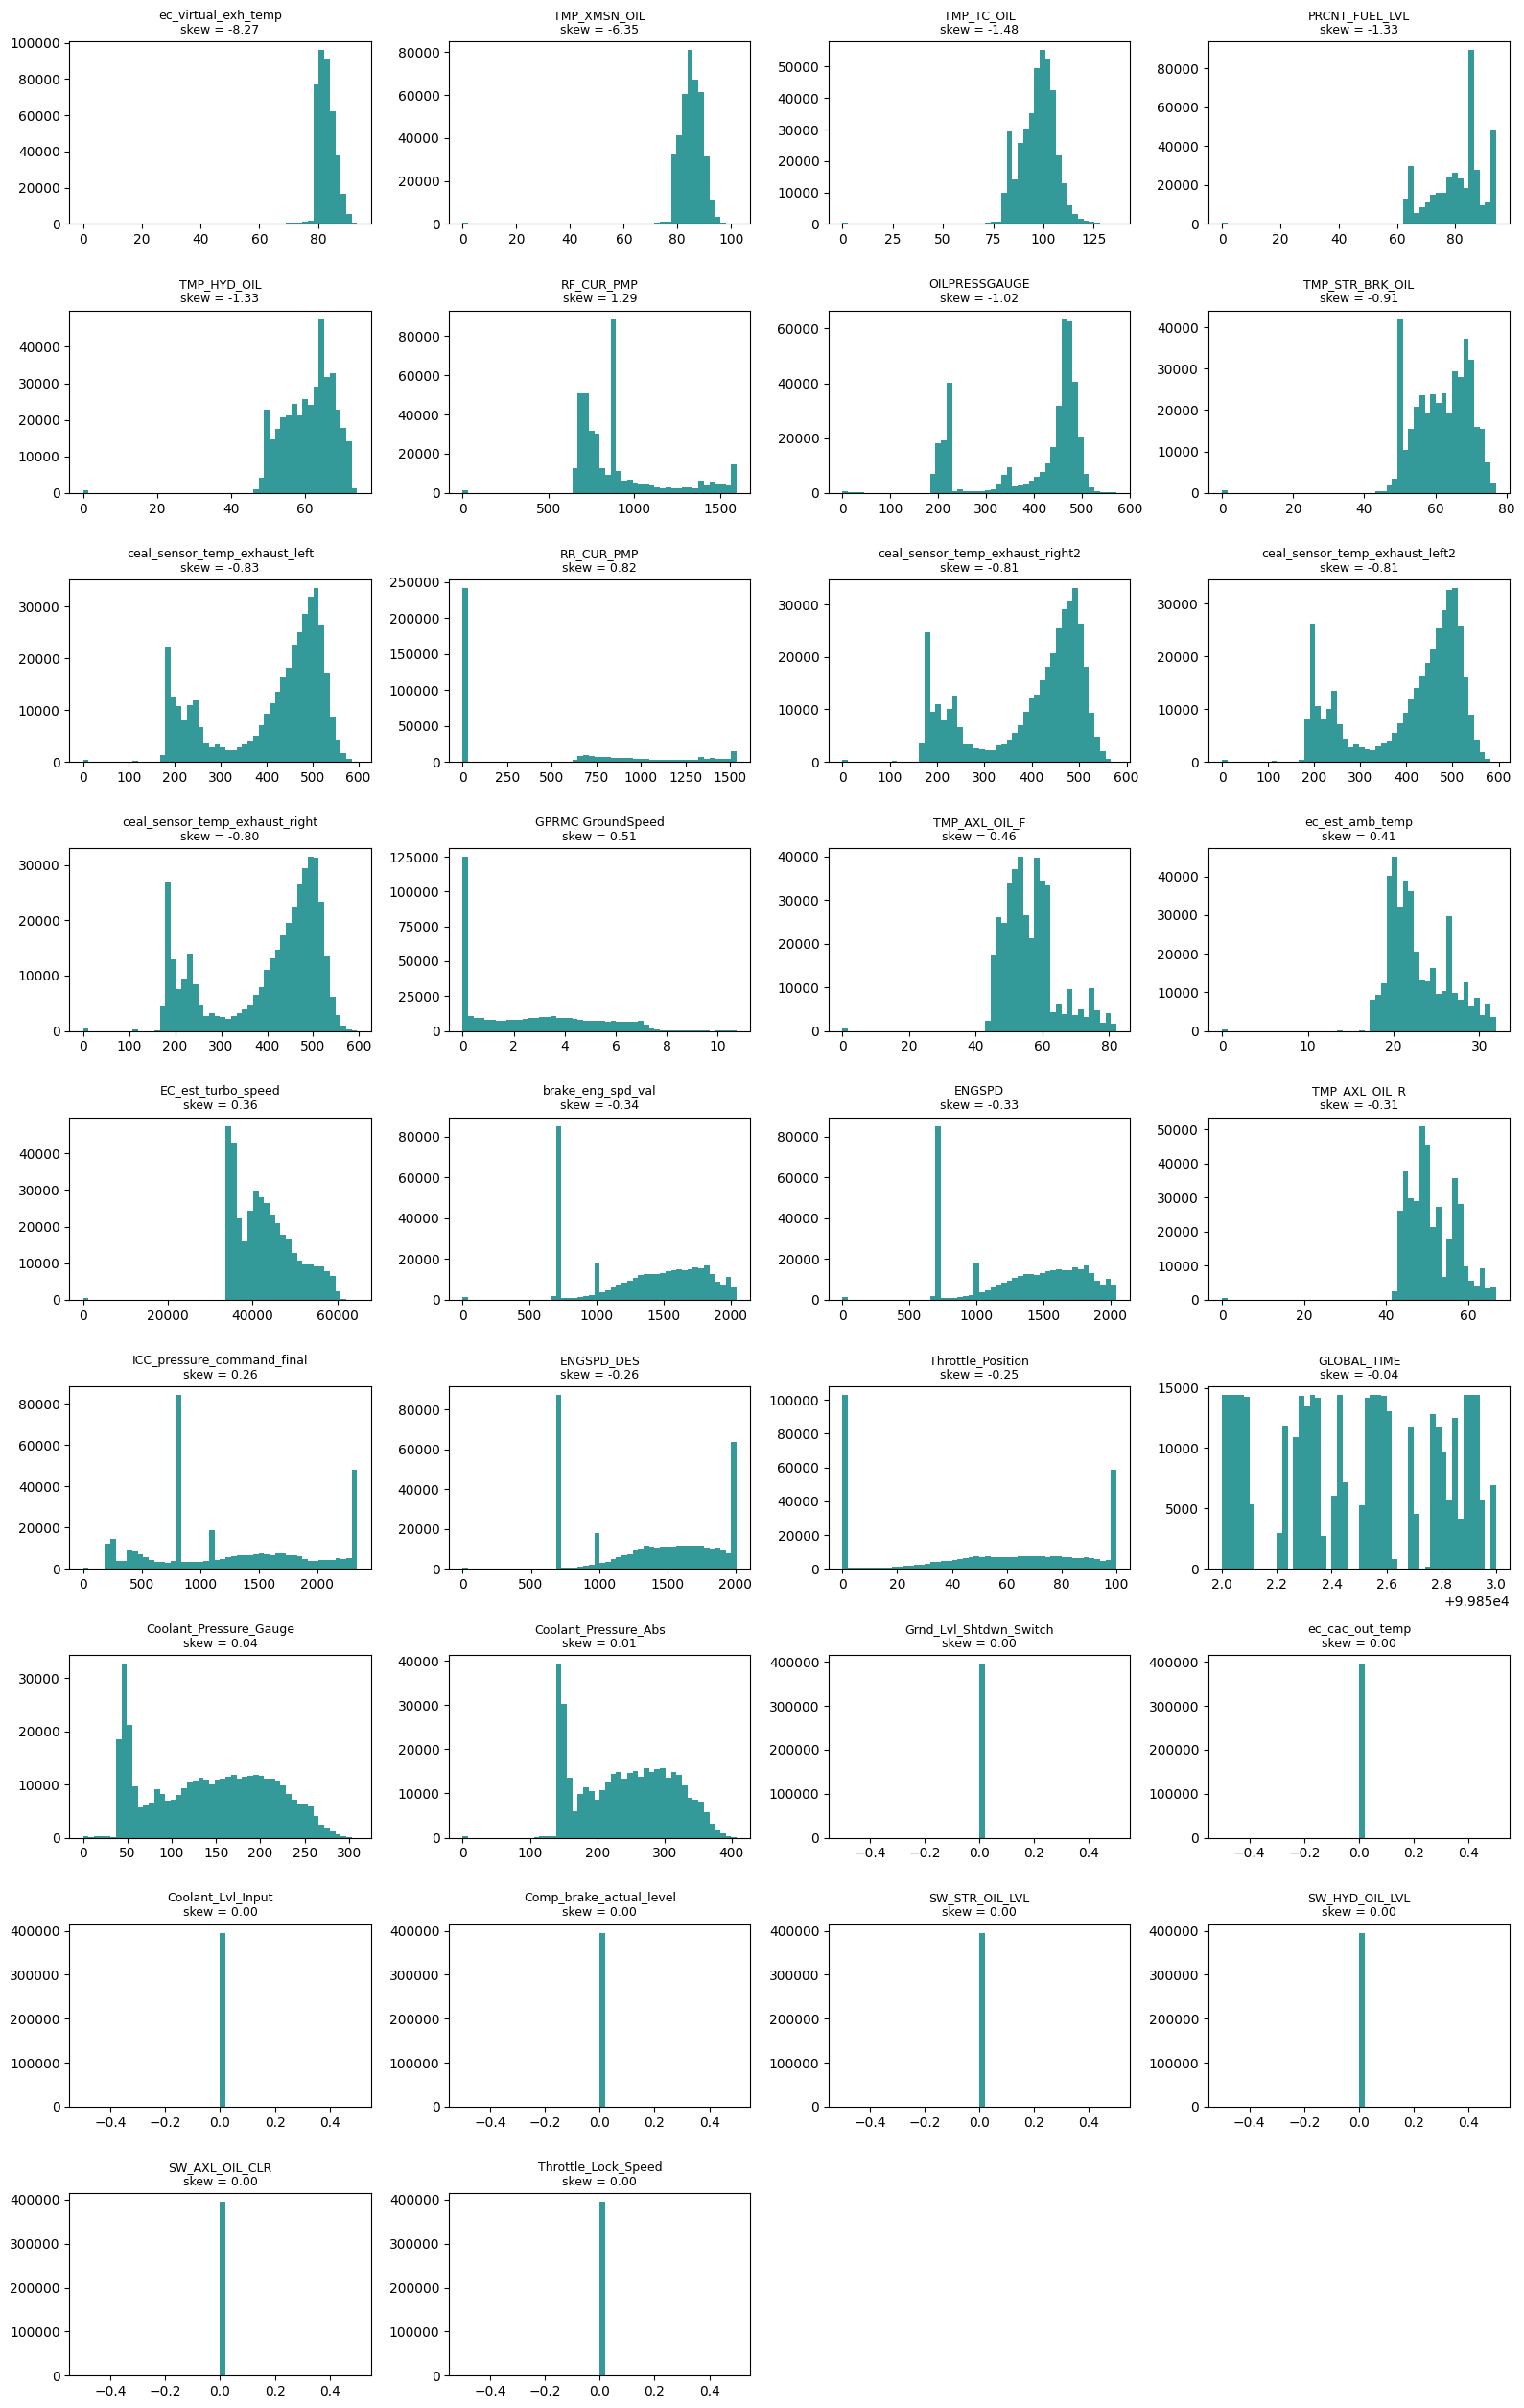

In [35]:
# Histogramas de TODAS las variables numéricas ordenadas por sesgo
all_skew = skew_table.index.tolist()
n = len(all_skew)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 2.8 * nrows))
axes = np.atleast_1d(axes).flatten()

for ax, col in zip(axes, all_skew):
    s = df[col].dropna()
    ax.hist(s, bins=50, color="teal", alpha=0.8)
    ax.set_title(f"{col}\nskew = {skew_table.loc[col, 'skew']:.2f}", fontsize=9)

# Apagar ejes sobrantes
for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout(); plt.show()


## 5. Detección de valores atípicos (outliers)

Aplicamos la regla del **IQR** (`x < Q1-1.5·IQR ∨ x > Q3+1.5·IQR`) por columna y resumimos la
proporción de outliers. Mostramos *boxplots* de las variables más afectadas.


In [36]:
def iqr_outlier_pct(series: pd.Series) -> float:
    s = series.dropna()
    if s.empty:
        return np.nan
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    if iqr == 0:
        return 0.0
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return float(((s < lo) | (s > hi)).mean() * 100)

num_active = [c for c in numeric_cols if c in df.columns]

outlier_pct = pd.Series(
    {c: iqr_outlier_pct(df[c]) for c in num_active}
).dropna().sort_values(ascending=False)

print("Top 15 variables con mayor % de outliers (IQR):")
display(outlier_pct.head(15).to_frame("outliers_%").round(2))
print(f"\nVariables con > 5% de outliers: {(outlier_pct > 5).sum()}")
print(f"Variables sin outliers (0%):    {(outlier_pct == 0).sum()}")


Top 15 variables con mayor % de outliers (IQR):


,outliers_%
RF_CUR_PMP,14.97
TMP_AXL_OIL_F,4.18
ec_virtual_exh_temp,1.54
TMP_TC_OIL,0.92
TMP_XMSN_OIL,0.61
OILPRESSGAUGE,0.30
PRCNT_FUEL_LVL,0.22
TMP_STR_BRK_OIL,0.16
TMP_HYD_OIL,0.16
TMP_AXL_OIL_R,0.12



Variables con > 5% de outliers: 1
Variables sin outliers (0%):    18


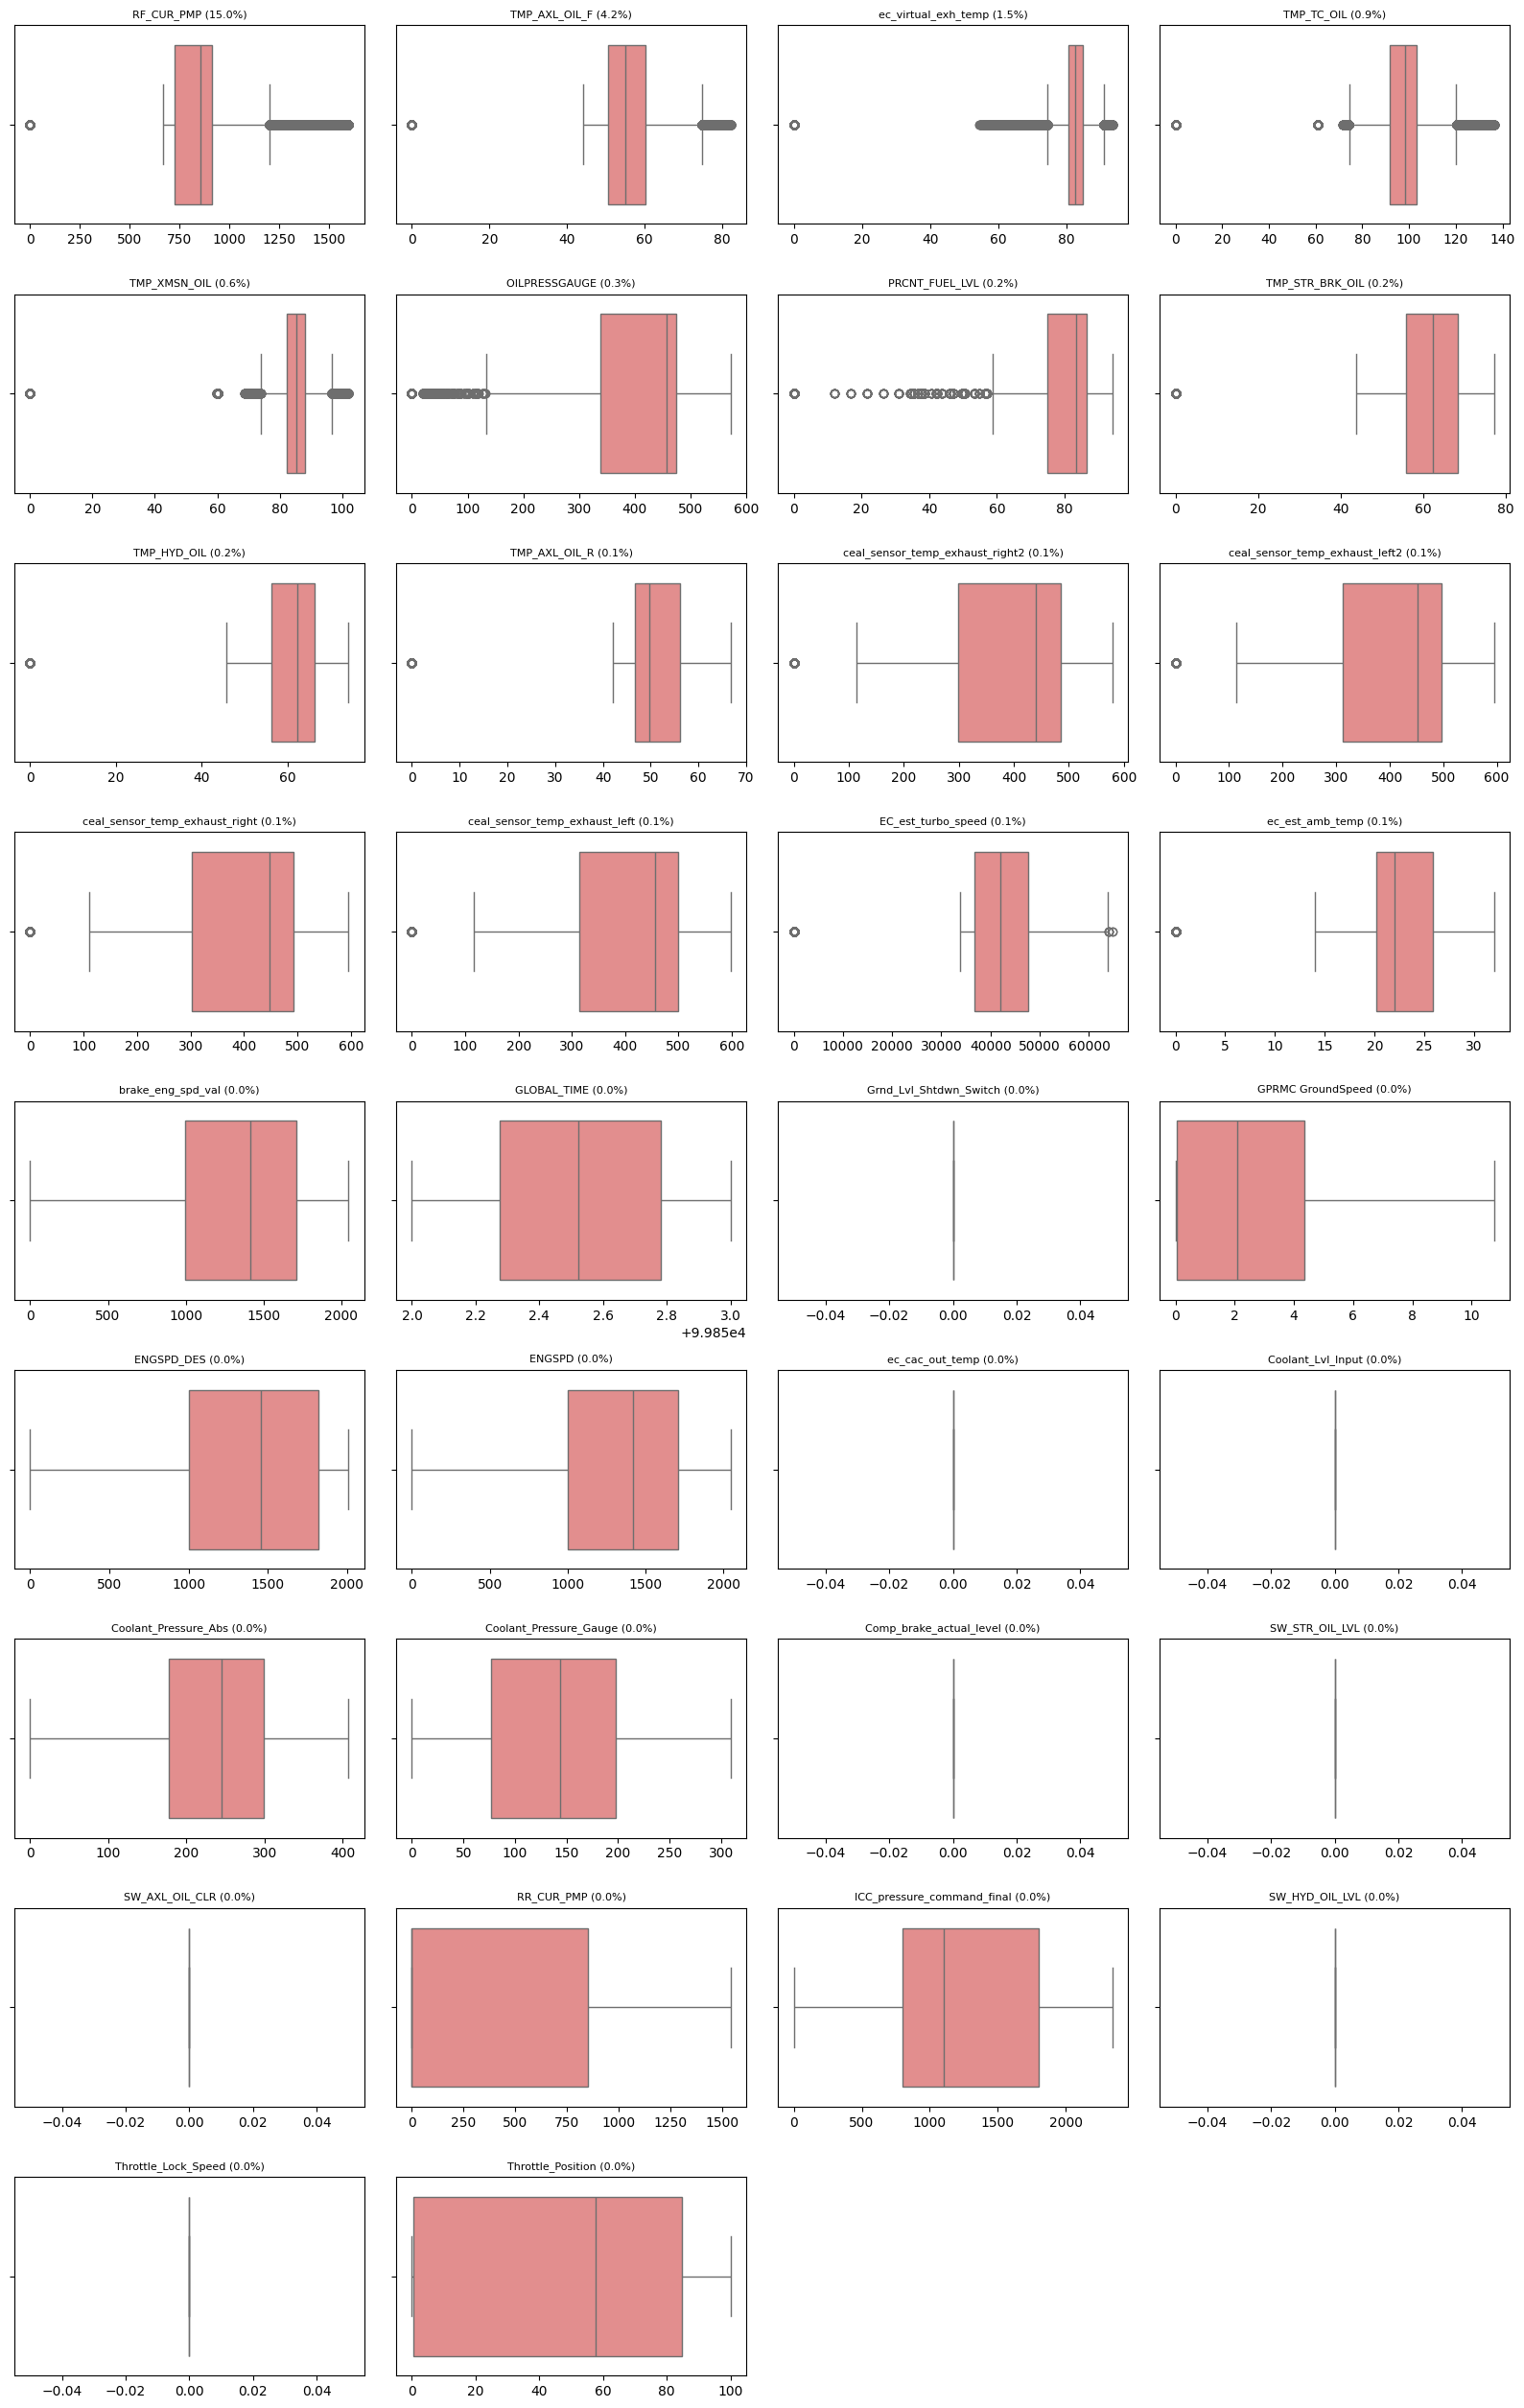

In [32]:
# Boxplots de TODAS las variables con outliers (% > 0)
cols_to_plot = outlier_pct.index.tolist()
n = len(cols_to_plot)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 2.8 * nrows))
axes = np.atleast_1d(axes).flatten()

for ax, col in zip(axes, cols_to_plot):
    sns.boxplot(x=df[col].dropna(), ax=ax, color="lightcoral")
    ax.set_title(f"{col} ({outlier_pct[col]:.1f}%)", fontsize=8)
    ax.set_xlabel("")

# Apagar ejes sobrantes
for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


## 6 Tendencias temporales

El dataset es una serie de tiempo (telemetría continua). Graficamos todas la variables como simples series de tiempo, tratano de localizar una tendencia obvia


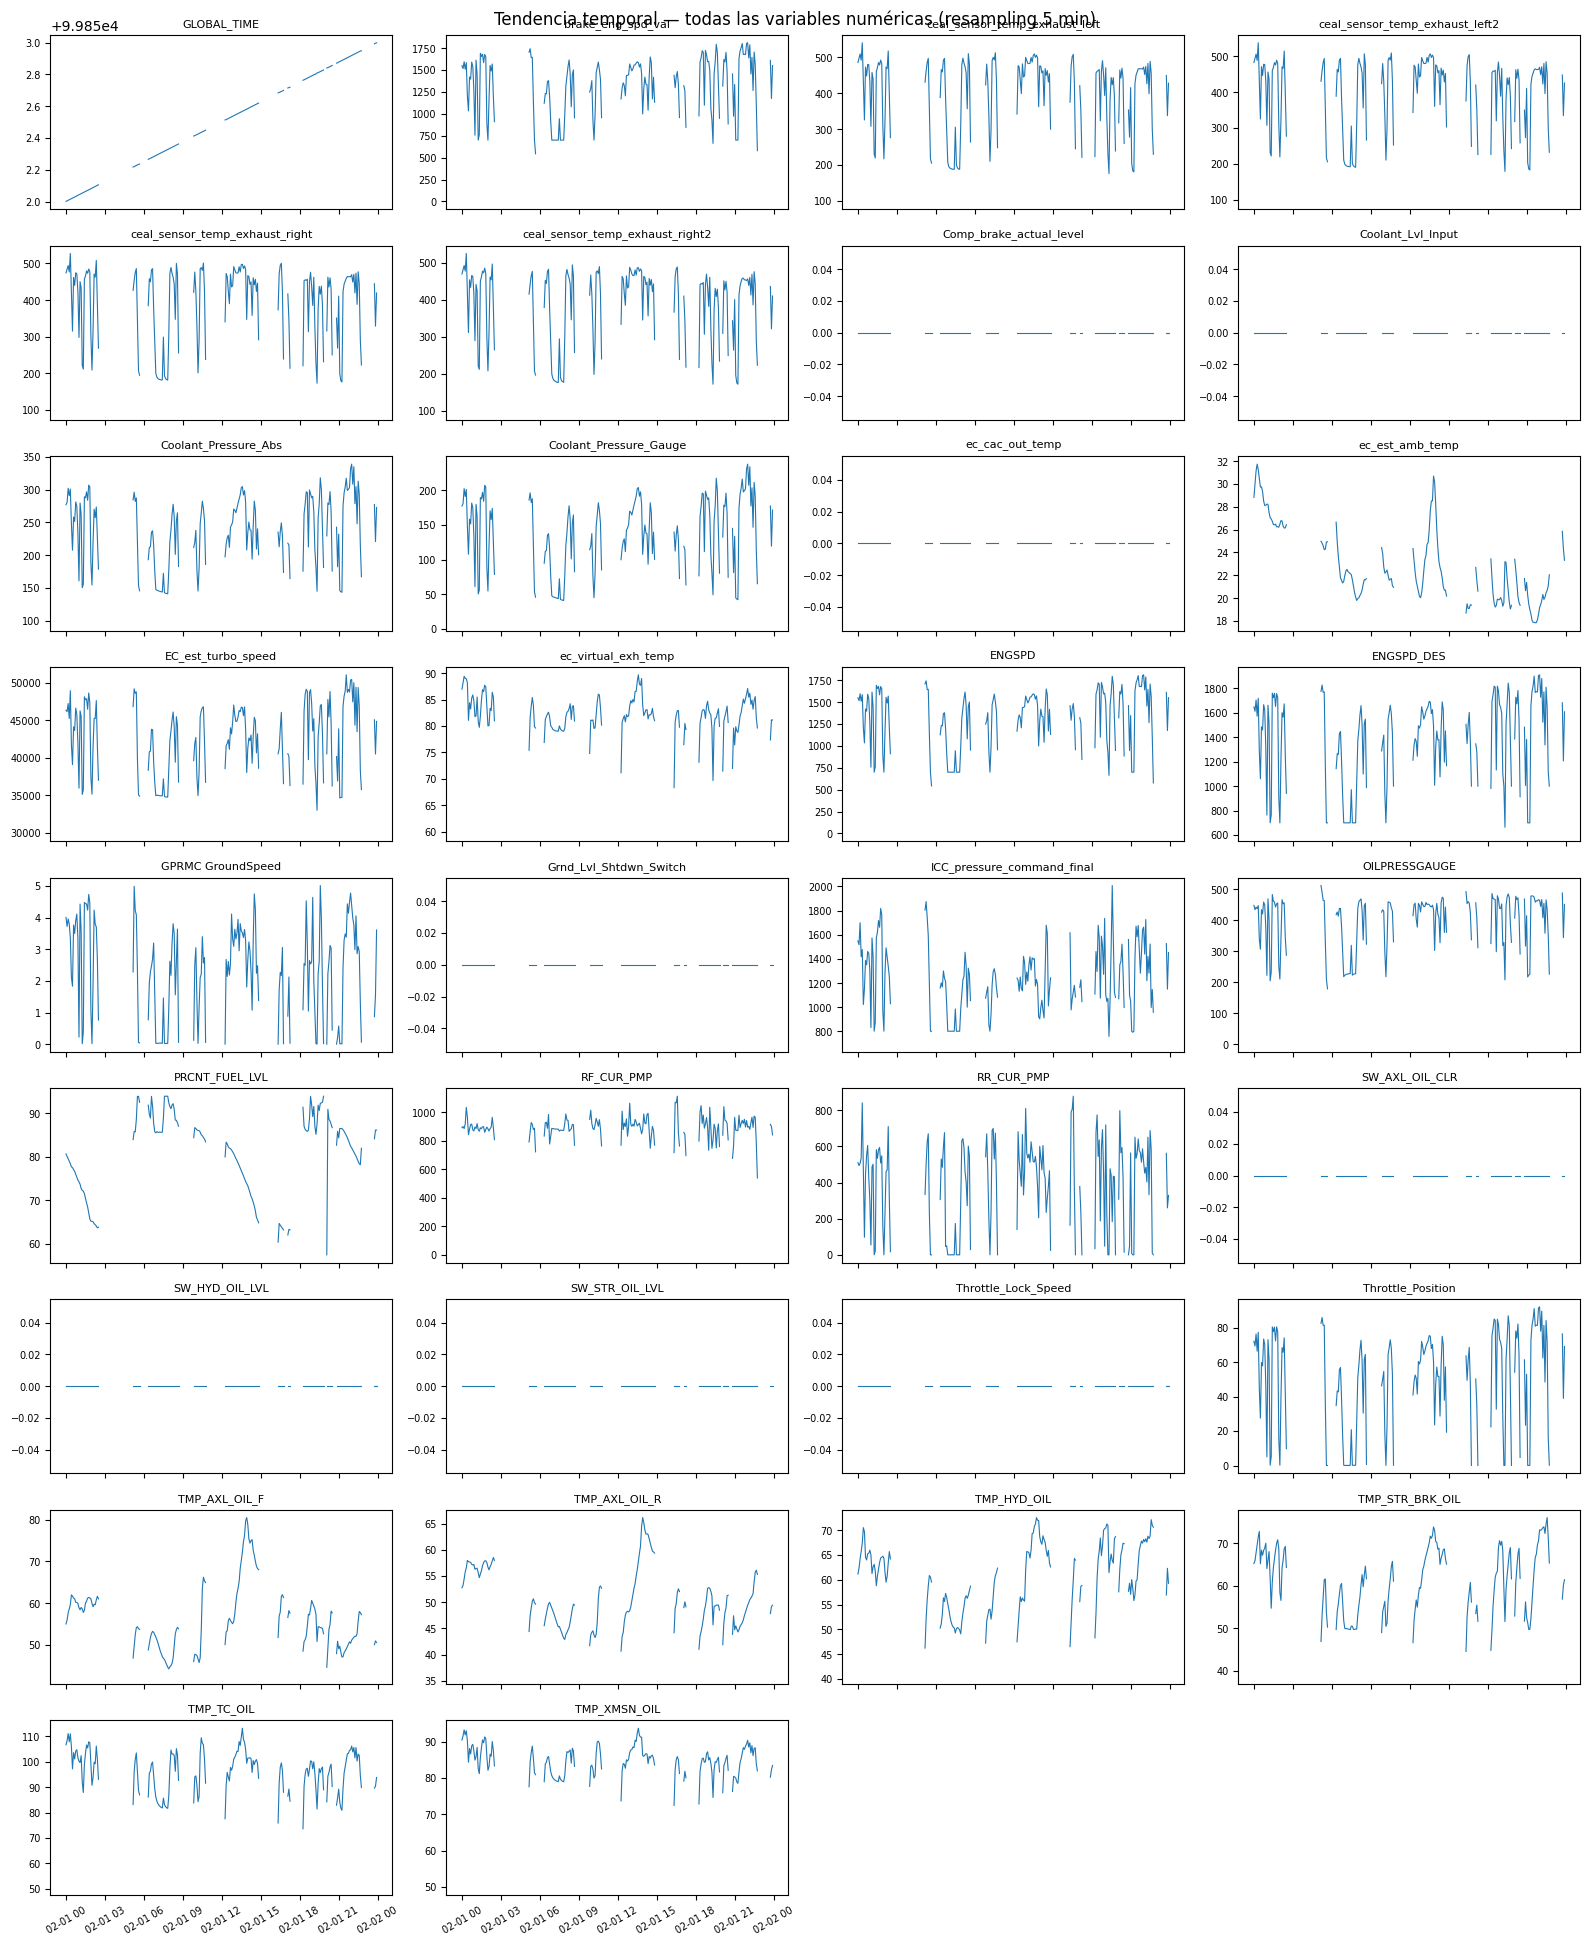

In [37]:
# Series de tiempo de TODAS las variables numéricas (formato 4 columnas)
ts_col = "date_time" if "date_time" in df.columns else None

if ts_col is not None and num_active:
    ts_df = (
        df.dropna(subset=[ts_col])
          .set_index(ts_col)[num_active]
          .resample("5min")
          .mean()
    )

    n = len(num_active)
    ncols = 4
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 2.2 * nrows), sharex=True)
    axes = np.atleast_1d(axes).flatten()

    for ax, col in zip(axes, num_active):
        ax.plot(ts_df.index, ts_df[col], lw=0.8)
        ax.set_title(col, fontsize=8)
        ax.tick_params(axis="x", labelsize=7, rotation=30)
        ax.tick_params(axis="y", labelsize=7)

    # Apagar ejes sobrantes
    for ax in axes[n:]:
        ax.set_visible(False)

    fig.suptitle("Tendencia temporal — todas las variables numéricas (resampling 5 min)")
    plt.tight_layout()
    plt.show()
else:
    print("No se encontró columna temporal o variables numéricas para graficar.")


## 7. Análisis bivariado y correlación

Dos enfoques complementarios:
- **Numérica vs numérica**: matriz de correlación (Pearson) sobre las variables más informativas.
- **Numérica vs `Status`**: ANOVA F-score para rankear qué variables separan mejor las clases.
- **Boxplots** de las 6 numéricas más discriminantes según F-score.


In [40]:
from sklearn.feature_selection import f_classif
from sklearn.impute import SimpleImputer

# Pre-filtro: descartar columnas con varianza muy baja o demasiados NaN para evitar ruido
filt = [
    c for c in num_active
    if df[c].isna().mean() < 0.5 and df[c].std(skipna=True) > 0
]
X_num = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(df[filt]),
    columns=filt,
)
y = df["status"].astype(str)

f_vals, p_vals = f_classif(X_num, y)
fscore = (
    pd.DataFrame({"F": f_vals, "p_value": p_vals}, index=filt)
    .sort_values("F", ascending=False)
)
print("Top 15 numéricas más discriminantes para Status (ANOVA F-score):")
display(fscore)


Top 15 numéricas más discriminantes para Status (ANOVA F-score):


,F,p_value
TMP_TC_OIL,92559.636157,0.000000e+00
ceal_sensor_temp_exhaust_left,77824.643507,0.000000e+00
ceal_sensor_temp_exhaust_left2,76173.136507,0.000000e+00
ceal_sensor_temp_exhaust_right2,76116.591339,0.000000e+00
ceal_sensor_temp_exhaust_right,74695.155379,0.000000e+00
TMP_XMSN_OIL,73149.638097,0.000000e+00
ec_virtual_exh_temp,66098.822952,0.000000e+00
TMP_STR_BRK_OIL,55789.774207,0.000000e+00
GPRMC GroundSpeed,52145.490966,0.000000e+00
Coolant_Pressure_Abs,48828.047907,0.000000e+00


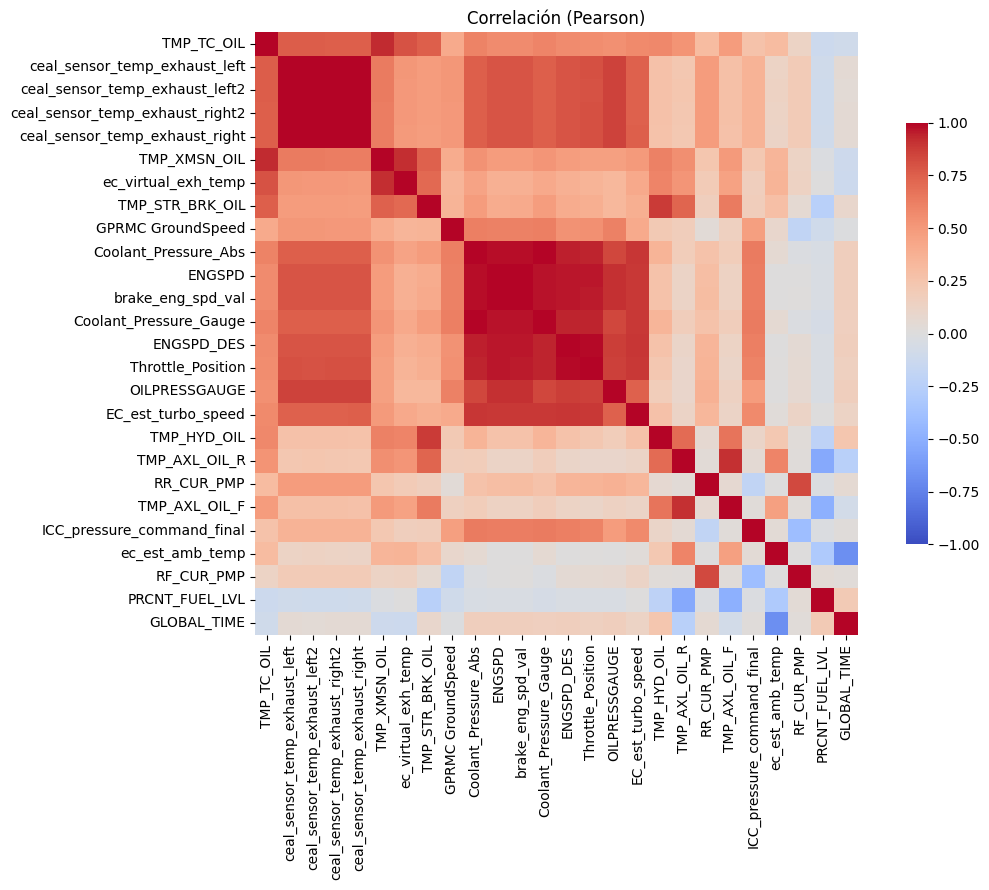


Pares con |r| > 0.95 (posible redundancia): 17


,,r
ceal_sensor_temp_exhaust_left,ceal_sensor_temp_exhaust_left2,0.999769
ceal_sensor_temp_exhaust_left2,ceal_sensor_temp_exhaust_right,0.999483
ceal_sensor_temp_exhaust_right2,ceal_sensor_temp_exhaust_right,0.999423
ceal_sensor_temp_exhaust_left,ceal_sensor_temp_exhaust_right,0.999345
ceal_sensor_temp_exhaust_left2,ceal_sensor_temp_exhaust_right2,0.999343
ceal_sensor_temp_exhaust_left,ceal_sensor_temp_exhaust_right2,0.999327
ENGSPD,brake_eng_spd_val,0.998606
Coolant_Pressure_Abs,Coolant_Pressure_Gauge,0.997691
ENGSPD_DES,Throttle_Position,0.990452
Coolant_Pressure_Abs,ENGSPD,0.977519


In [44]:
# Heatmap de correlación entre las top 20 variables más discriminantes
top20 = fscore.index.tolist()
corr = df[top20].corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            square=True, ax=ax, annot=False, cbar_kws={"shrink": 0.7})
ax.set_title("Correlación (Pearson)")
plt.tight_layout(); plt.show()

# Pares altamente correlacionados (|r| > 0.95) — candidatos a redundancia
upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
high_corr = (
    upper.stack()
    .pipe(lambda s: s[s.abs() > 0.95])
    .sort_values(key=np.abs, ascending=False)
)
print(f"\nPares con |r| > 0.95 (posible redundancia): {len(high_corr)}")
display(high_corr.to_frame("r"))


C:\Users\alvarjl3\AppData\Local\Temp\ipykernel_39856\2506840517.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=status_series, y=df[col], ax=ax,
C:\Users\alvarjl3\AppData\Local\Temp\ipykernel_39856\2506840517.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=status_series, y=df[col], ax=ax,
C:\Users\alvarjl3\AppData\Local\Temp\ipykernel_39856\2506840517.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=status_series, y=df[col], ax=ax,
C:\Users\alvarjl3\AppData\Local\Temp\ipykernel_39856\2506840517.py:16: FutureWarning: 

Pas

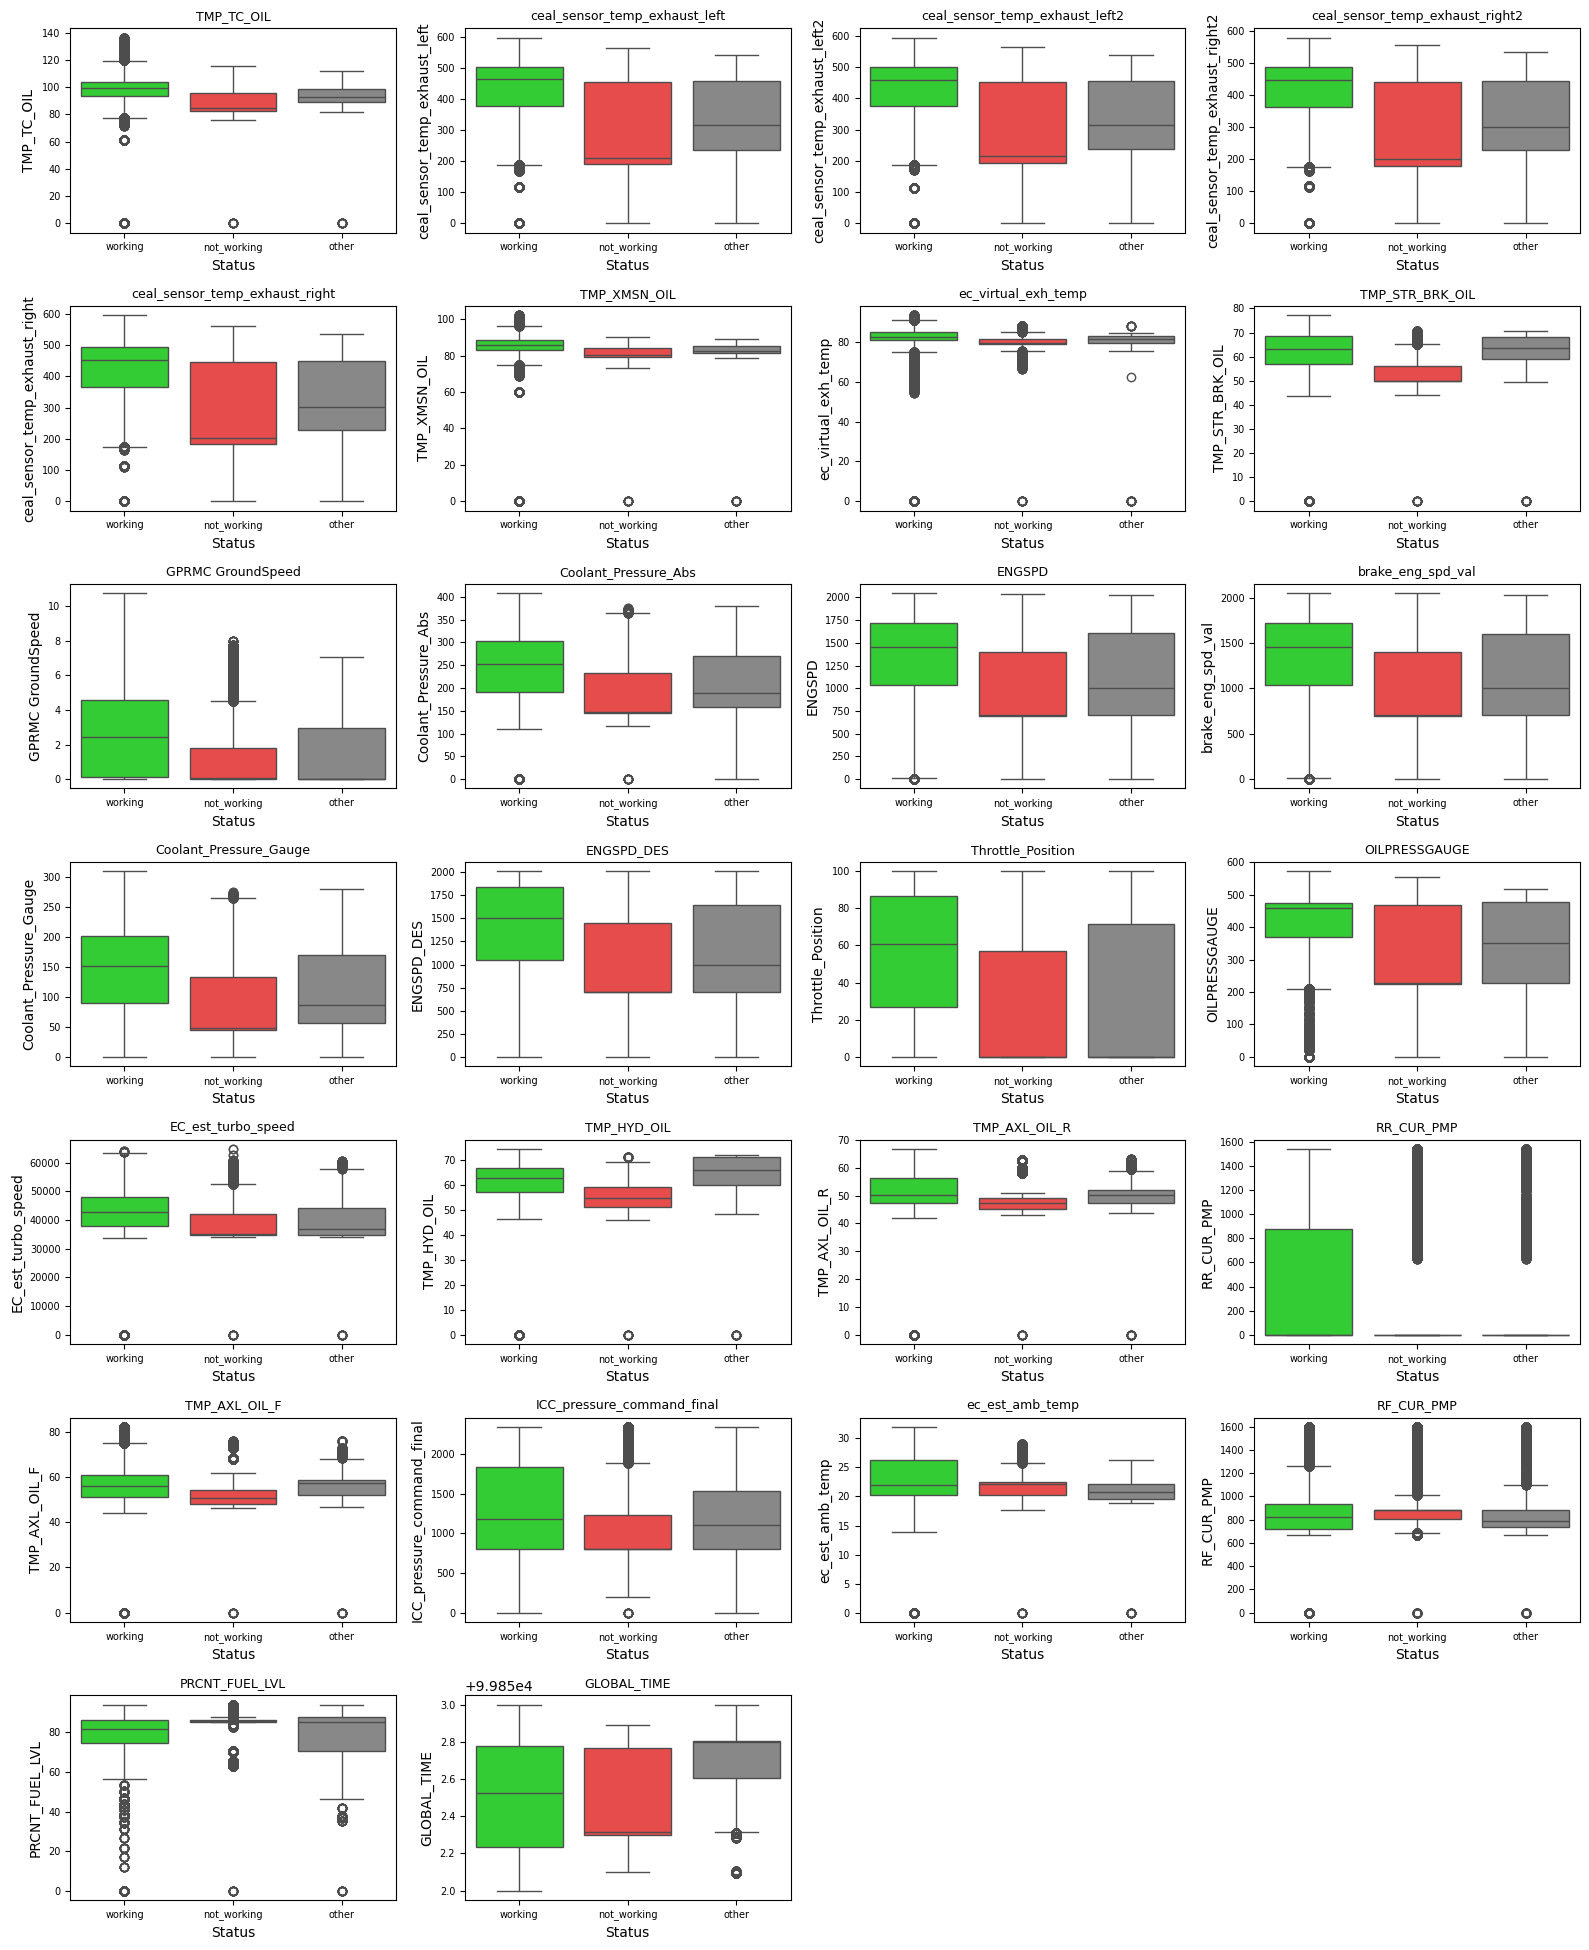

In [48]:
# Boxplots por Status para TODAS las variables (formato 4 columnas)
# Construir Status a partir de las máscaras working / not_working (no existe la columna)
status_series = pd.Series("other", index=df.index, dtype="object")
status_series[working]     = "working"
status_series[not_working] = "not_working"

cols_to_plot = fscore.index.tolist()
n = len(cols_to_plot)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 2.8 * nrows))
axes = np.atleast_1d(axes).flatten()

for ax, col in zip(axes, cols_to_plot):
    sns.boxplot(x=status_series, y=df[col], ax=ax,
                order=["working", "not_working", "other"],
                palette={"working": "#1ae61a", "not_working": "#ff3333", "other": "#888888"})
    ax.set_xlabel("Status")
    ax.set_title(col, fontsize=9)
    ax.tick_params(axis="x", labelsize=7)
    ax.tick_params(axis="y", labelsize=7)

# Apagar ejes sobrantes
for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout(); plt.show()


## 8. Balance de la variable objetivo

Distribución de clases en `Status`. Si una clase domina (>80%) hay desbalance que justifica
estrategias como `class_weight="balanced"`, *resampling* (SMOTE / undersampling) o métricas
robustas (F1 macro, balanced accuracy) en lugar de *accuracy*.


Distribución de status:
                  n      %
status                    
working      355369  89.94
not_working   39739  10.06

Gap entre clase mayor y menor: 79.9 puntos
⚠ Desbalance considerable


C:\Users\alvarjl3\AppData\Local\Temp\ipykernel_39856\3722718774.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


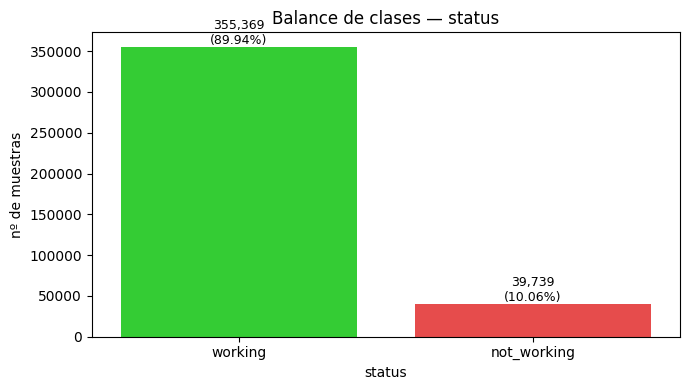

In [56]:
counts = df["status"].value_counts()
pct    = (counts / counts.sum() * 100).round(2)
balance = pd.concat([counts, pct], axis=1)
balance.columns = ["n", "%"]
print("Distribución de status:")
print(balance)

imbalance = pct.max() - pct.min()
print(f"\nGap entre clase mayor y menor: {imbalance:.1f} puntos")
print("⚠ Desbalance considerable" if imbalance > 60 else "✓ Balance aceptable")

palette = {"working": "#1ae61a", "not_working": "#ff3333", "other": "#888888"}

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    x=counts.index, y=counts.values, ax=ax,
    palette=[palette.get(c, "#1f77b4") for c in counts.index],
)
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}\n({pct.iloc[i]}%)", ha="center", va="bottom", fontsize=9)
ax.set_title("Balance de clases — status")
ax.set_ylabel("nº de muestras")
plt.tight_layout(); plt.show()


In [ ]:
# Guardar resultados para la siguiente parte del pipeline
import json
from pathlib import Path

eda_artifacts = {
    "serial_number": SERIAL_NUMBER,
    "date_range": [str(START_DATE), str(STOP_DATE)],
    "n_rows": int(len(df)),
    "n_cols": int(df.shape[1]),
    "lat_col": lat_col,
    "lon_col": lon_col,
    "ts_col": ts_col,
    "numeric_cols": numeric_cols,
    "categorical_cols": categorical_cols,
    "datetime_cols": datetime_cols,
    "high_missing_cols":   missing_pct[missing_pct > 90].index.tolist(),
    "constant_cols":       [
        c for c in numeric_cols if c in df.columns and df[c].nunique(dropna=True) <= 1
    ],
    "skewed_features":      skewed_features,
    "high_outlier_cols":    outlier_pct[outlier_pct > 5].index.tolist(),
    "redundant_pairs":      [list(idx) for idx in high_corr.index.tolist()],
    "status_balance":       balance.to_dict(),
}

out = Path("eda_artifacts.json")
out.write_text(json.dumps(eda_artifacts, indent=2, default=str))
print(f"Resumen del EDA guardado en: {out.resolve()}")


Resumen del EDA guardado en: C:\Users\alvarjl3\Documents\Repos\Downtime_Analysis\eda_artifacts.json


## Conclusiones

- **Variables sin variabilidad:** Algunos canales presentan varianza nula o casi nula a lo largo de toda la ventana. Esto suele indicar que el sensor no está activo en esta máquina o que reporta un valor constante. Estas variables deben **eliminarse** antes del modelado, ya que no aportan información discriminante.
- **Alta correlación / redundancia:** Existen pares de variables con `|r| > 0.95`, lo que sugiere mediciones redundantes (sensores que capturan el mismo fenómeno físico). Se recomienda **descartar una de cada par redundante** o aplicar reducción de dimensionalidad (PCA) para evitar multicolinealidad en los modelos.
- **Outliers por errores de medición:** Varias variables muestran outliers que no corresponden a comportamiento operativo real, sino a fallos del sensor — por ejemplo `TMP_AXL_OIL_R = 0`, físicamente imposible para un aceite en operación. Estos casos deben **filtrarse o imputarse** (winsorización, reemplazo por NaN + imputación con la mediana) en lugar de tratarse como observaciones válidas.

- **Siguientes pasos:** Agregar y remover variables disponibles que puedan enriquecer el modelo y iniciar conclustering para tratar de evaluar si la creación de clases con GPS es adecuada, y comenzar con modelos base
